In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Create a synthetic dataset if it doesn't exist
def generate_churn_data(n=1000):
    np.random.seed(42)
    data = {
        'customer_id': range(1, n + 1),
        'tenure_months': np.random.randint(1, 72, n),
        'contract_type': np.random.choice(['Month-to-Month', 'One Year', 'Two Year'], n),
        'monthly_charges': np.random.uniform(20, 120, n),
        'total_charges': 0,
        'support_tickets': np.random.randint(0, 10, n),
        'churn': 0
    }
    df = pd.DataFrame(data)
    df['total_charges'] = df['tenure_months'] * df['monthly_charges']

    # Logic: Higher churn if Month-to-Month and high support tickets
    churn_logic = (
        (df['contract_type'] == 'Month-to-Month') &
        (df['support_tickets'] > 4) |
        (df['tenure_months'] < 6)
    )
    df.loc[churn_logic, 'churn'] = np.random.choice([0, 1], size=churn_logic.sum(), p=[0.3, 0.7])
    return df

os.makedirs('../data', exist_ok=True)
df = generate_churn_data()
df.to_csv('../data/customer_data.csv', index=False)
print("Dataset created in data/customer_data.csv")

Dataset created in data/customer_data.csv


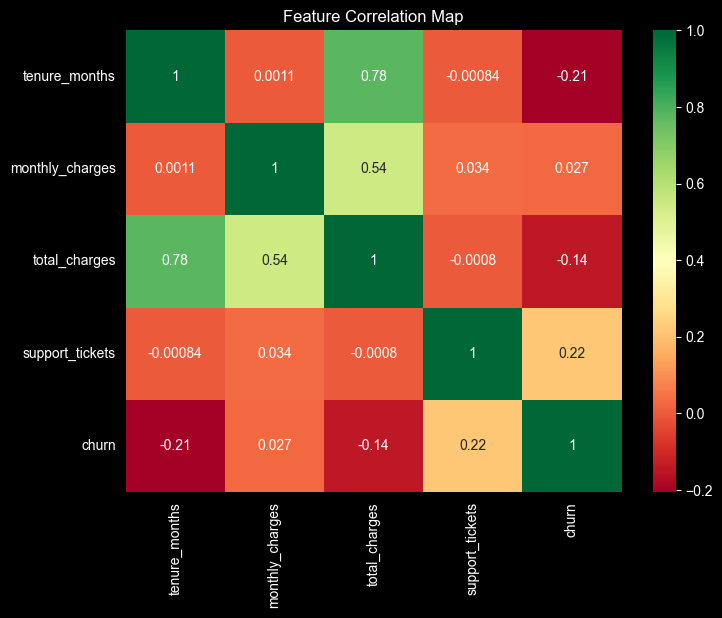

In [3]:
# Change line 9 to include numeric_only=True
plt.figure(figsize=(8, 6))
correlation_matrix = df.drop('customer_id', axis=1).corr(numeric_only=True) # <--- Add this
sns.heatmap(correlation_matrix, annot=True, cmap='RdYlGn')
plt.title('Feature Correlation Map')
plt.show()